Import libraries and load Brown corpus

In [8]:
import nltk
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from nltk.corpus import brown
from nltk import FreqDist, bigrams
import string

# Load Brown corpus (if not already downloaded)
nltk.download('brown')
nltk.download('universal_tagset')  # universal tagset (12 coarse tags)

# Get tagged sentences with universal tagset
tagged_sents = list(brown.tagged_sents(tagset='universal'))   # explicit conversion to list
print(f"Total sentences: {len(tagged_sents)}")

# Split into training (80%) and testing (20%)
random.seed(42)
random.shuffle(tagged_sents)
split = int(0.8 * len(tagged_sents))
train_sents = tagged_sents[:split]
test_sents = tagged_sents[split:]

# Collect all tags from the universal tagset
all_tags = sorted({tag for sent in tagged_sents for word, tag in sent})
tag2idx = {tag: i for i, tag in enumerate(all_tags)}
idx2tag = {i: tag for tag, i in tag2idx.items()}
num_tags = len(all_tags)
print("Tags:", all_tags)

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


Total sentences: 57340
Tags: ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']


HMM Tagger with Viterbi decoding

In [9]:
# ============================================================
# 1. HMM Tagger base class
# ============================================================
class HMMTagger:
    def __init__(self, unknown_handler):
        """
        unknown_handler: object with method get_emission_vector(word)
                         returning a numpy array of probabilities over tags (length num_tags)
        """
        self.unknown_handler = unknown_handler
        self.trans = None      # transition matrix (num_tags x num_tags)
        self.emission = None   # emission matrix for known words
        self.vocab = set()     # vocabulary of known words

    def train(self, tagged_sentences, smoothing=1e-6):
        """Train HMM: estimate transition and emission probabilities"""
        # Collect counts
        trans_counts = np.zeros((num_tags, num_tags))
        emit_counts = defaultdict(lambda: np.zeros(num_tags))
        tag_counts = np.zeros(num_tags)

        for sent in tagged_sentences:
            prev_tag = None
            for word, tag in sent:
                tag_idx = tag2idx[tag]
                tag_counts[tag_idx] += 1
                emit_counts[word][tag_idx] += 1
                self.vocab.add(word)
                if prev_tag is not None:
                    trans_counts[prev_tag, tag_idx] += 1
                prev_tag = tag_idx
            # No dummy transition needed

        # Additive smoothing for transitions
        self.trans = (trans_counts + smoothing) / (trans_counts.sum(axis=1, keepdims=True) + smoothing * num_tags)

        # Emission probabilities for known words – with additive smoothing
        self.emission = {}
        for word, counts in emit_counts.items():
            smoothed = counts + smoothing
            self.emission[word] = smoothed / smoothed.sum()

    def viterbi(self, words):
        """Decode a sequence of words into tags using the Viterbi algorithm"""
        n = len(words)
        if n == 0:
            return []
        # Initialization
        dp = np.zeros((num_tags, n))
        back = np.zeros((num_tags, n), dtype=int)

        # First word
        word0 = words[0]
        if word0 in self.emission:
            emit0 = self.emission[word0]
        else:
            emit0 = self.unknown_handler.get_emission_vector(word0)
        # Initial probability: uniform for simplicity
        start_prob = 1.0 / num_tags
        for s in range(num_tags):
            dp[s, 0] = np.log(start_prob) + np.log(max(emit0[s], 1e-12))

        # Recursion
        for i in range(1, n):
            word = words[i]
            if word in self.emission:
                emit = self.emission[word]
            else:
                emit = self.unknown_handler.get_emission_vector(word)
            for s in range(num_tags):
                best = -np.inf
                best_prev = 0
                for prev in range(num_tags):
                    score = dp[prev, i-1] + np.log(max(self.trans[prev, s], 1e-12)) + np.log(max(emit[s], 1e-12))
                    if score > best:
                        best = score
                        best_prev = prev
                dp[s, i] = best
                back[s, i] = best_prev

        # Termination and backtracking
        last_best = np.argmax(dp[:, -1])
        tags_idx = [last_best]
        for i in range(n-1, 0, -1):
            last_best = back[last_best, i]
            tags_idx.append(last_best)
        tags_idx.reverse()
        return [idx2tag[idx] for idx in tags_idx]

    def evaluate(self, test_sentences):
        """Evaluate accuracy on test sentences (words + tags)"""
        correct = 0
        total = 0
        unknown_correct = 0
        unknown_total = 0
        for sent in test_sentences:
            words = [word for word, tag in sent]
            true_tags = [tag for word, tag in sent]
            pred_tags = self.viterbi(words)
            for w, t_true, t_pred in zip(words, true_tags, pred_tags):
                total += 1
                if t_true == t_pred:
                    correct += 1
                # Count unknown words separately
                if w not in self.vocab:
                    unknown_total += 1
                    if t_true == t_pred:
                        unknown_correct += 1
        acc = correct / total if total > 0 else 0
        unk_acc = unknown_correct / unknown_total if unknown_total > 0 else 0
        return acc, unk_acc

Unknown‑word handlers (6 strategies)

In [10]:
# ============================================================
# 2. Unknown‑word handlers
# ============================================================

# 2.1 Baseline: uniform distribution
class UniformUnknownHandler:
    def get_emission_vector(self, word):
        return np.full(num_tags, 1.0 / num_tags)

# 2.2 Suffix‑based heuristic (lengths 1..5)
class SuffixUnknownHandler:
    def __init__(self, train_sents, min_freq=3):
        # Build suffix dictionary (length 1..5 characters) -> tag distribution
        self.suffix_counts = defaultdict(lambda: np.zeros(num_tags))
        suffix_len = [1,2,3,4,5]
        for sent in train_sents:
            for word, tag in sent:
                tag_idx = tag2idx[tag]
                for l in suffix_len:
                    if len(word) >= l:
                        suffix = word[-l:]
                        self.suffix_counts[suffix][tag_idx] += 1
        # Convert to probabilities (with slight smoothing)
        self.suffix_probs = {}
        for suffix, counts in self.suffix_counts.items():
            total = counts.sum()
            if total >= min_freq:
                self.suffix_probs[suffix] = (counts + 1e-6) / (total + 1e-6 * num_tags)
        # For unknown suffixes – uniform distribution
        self.default_probs = np.full(num_tags, 1.0 / num_tags)

    def get_emission_vector(self, word):
        # Try suffixes from longest to shortest
        for l in range(min(5, len(word)), 0, -1):
            suffix = word[-l:]
            if suffix in self.suffix_probs:
                return self.suffix_probs[suffix]
        return self.default_probs

# 2.3 Pseudo‑word classes
class PseudoClassUnknownHandler:
    def __init__(self, train_sents):
        # Define classes and their emission distributions
        self.classes = {
            'NUM': self.is_number,
            'ALLCAPS': self.is_allcaps,
            'CAPITALIZED': self.is_capitalized,
            'HAS_HYPHEN': self.has_hyphen,
            'MIXED_DIGIT': self.has_digit,
        }
        self.class_counts = defaultdict(lambda: np.zeros(num_tags))
        # Count on training data
        for sent in train_sents:
            for word, tag in sent:
                tag_idx = tag2idx[tag]
                for cls_name, check_func in self.classes.items():
                    if check_func(word):
                        self.class_counts[cls_name][tag_idx] += 1
        # Normalize
        self.class_probs = {}
        for cls_name, counts in self.class_counts.items():
            total = counts.sum()
            if total > 0:
                self.class_probs[cls_name] = (counts + 1e-6) / (total + 1e-6 * num_tags)
            else:
                self.class_probs[cls_name] = np.full(num_tags, 1.0 / num_tags)
        self.default_probs = np.full(num_tags, 1.0 / num_tags)

    @staticmethod
    def is_number(word):
        try:
            float(word)
            return True
        except:
            return False

    @staticmethod
    def is_allcaps(word):
        return word.isupper() and len(word) > 1

    @staticmethod
    def is_capitalized(word):
        return word[0].isupper() and word[1:].islower() if len(word) > 1 else word.isupper()

    @staticmethod
    def has_hyphen(word):
        return '-' in word

    @staticmethod
    def has_digit(word):
        return any(c.isdigit() for c in word)

    def get_emission_vector(self, word):
        # Apply the first matching class
        for cls_name, check_func in self.classes.items():
            if check_func(word):
                return self.class_probs[cls_name]
        return self.default_probs

# 2.4 Character n‑grams (prefixes + suffixes)
class CharNgramUnknownHandler:
    def __init__(self, train_sents, n=3, min_freq=2):
        # Use character n‑grams (prefixes and suffixes)
        self.ngram_counts = defaultdict(lambda: np.zeros(num_tags))
        # For each word in training
        for sent in train_sents:
            for word, tag in sent:
                tag_idx = tag2idx[tag]
                # Add prefixes and suffixes of length 1..n
                for l in range(1, n+1):
                    if len(word) >= l:
                        pref = word[:l]
                        suff = word[-l:]
                        self.ngram_counts[pref][tag_idx] += 1
                        self.ngram_counts[suff][tag_idx] += 1
        # Convert to probabilities
        self.ngram_probs = {}
        for ngram, counts in self.ngram_counts.items():
            total = counts.sum()
            if total >= min_freq:
                self.ngram_probs[ngram] = (counts + 1e-6) / (total + 1e-6 * num_tags)
        self.default_probs = np.full(num_tags, 1.0 / num_tags)

    def get_emission_vector(self, word):
        # Collect all n‑grams (prefixes & suffixes)
        scores = np.zeros(num_tags)
        weights = 0
        for l in range(1, 4):
            if len(word) >= l:
                pref = word[:l]
                suff = word[-l:]
                if pref in self.ngram_probs:
                    scores += self.ngram_probs[pref]
                    weights += 1
                if suff in self.ngram_probs:
                    scores += self.ngram_probs[suff]
                    weights += 1
        if weights > 0:
            return scores / weights
        else:
            return self.default_probs

# 2.5 Hybrid handler (priority: pseudo‑class -> suffix -> char n‑gram -> uniform)
class HybridUnknownHandler:
    def __init__(self, train_sents):
        self.pseudo = PseudoClassUnknownHandler(train_sents)
        self.suffix = SuffixUnknownHandler(train_sents)
        self.char = CharNgramUnknownHandler(train_sents)
        self.uniform = UniformUnknownHandler()

    def get_emission_vector(self, word):
        # Check pseudo‑classes first
        for cls_name, check_func in self.pseudo.classes.items():
            if check_func(word):
                return self.pseudo.class_probs.get(cls_name, self.pseudo.default_probs)
        # Then suffixes
        vec = self.suffix.get_emission_vector(word)
        if not np.array_equal(vec, self.suffix.default_probs):
            return vec
        # Then character backoff
        vec2 = self.char.get_emission_vector(word)
        if not np.array_equal(vec2, self.char.default_probs):
            return vec2
        # Finally uniform
        return self.uniform.get_emission_vector(word)

Experiment with additional smoothing options

Running experiments with different Add-k smoothing variants...

=== Training on 5% of data ===
  Run 1/1 ...
    Evaluating Uniform...
        Overall Acc=0.8948, Unknown Acc=0.4716
    Evaluating Suffix...
        Overall Acc=0.9384, Unknown Acc=0.7909
    Evaluating PseudoClass...
        Overall Acc=0.9088, Unknown Acc=0.5753
    Evaluating CharNgram...
        Overall Acc=0.9299, Unknown Acc=0.7300
    Evaluating Hybrid...
        Overall Acc=0.9360, Unknown Acc=0.7732
    Evaluating AddK_0.1...
        Overall Acc=0.9027, Unknown Acc=0.5307
    Evaluating AddK_0.5...
        Overall Acc=0.9027, Unknown Acc=0.5306
    Evaluating AddK_1.0...
        Overall Acc=0.9028, Unknown Acc=0.5308
   5% completed.

=== Training on 10% of data ===
  Run 1/1 ...
    Evaluating Uniform...
        Overall Acc=0.9142, Unknown Acc=0.4551
    Evaluating Suffix...
        Overall Acc=0.9486, Unknown Acc=0.8042
    Evaluating PseudoClass...
        Overall Acc=0.9260, Unknown Acc=0.5757
    Evaluating

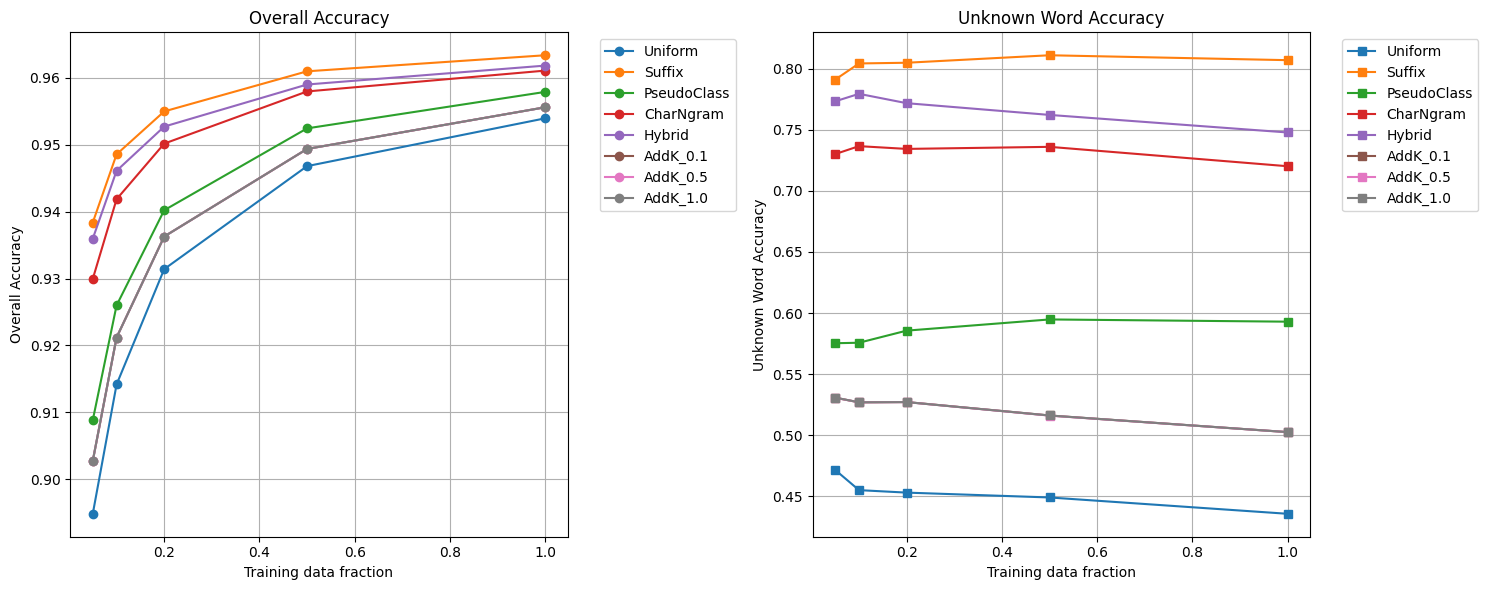


Best strategy at 5% data: Suffix
Unknown word accuracy: 0.7909


In [14]:
# ============================================================
# Add-k Smoothing Handler for unknown words
# ============================================================

class AddKUnknownHandler:
    def __init__(self, train_sents, k=1.0):
        """
        Add-k smoothing for unknown words.
        P(tag) = (count(tag) + k) / (total_tokens + k * num_tags)
        """
        tag_counts = np.zeros(num_tags)
        total_tokens = 0

        for sent in train_sents:
            for _, tag in sent:
                tag_counts[tag2idx[tag]] += 1
                total_tokens += 1

        self.probs = (tag_counts + k) / (total_tokens + k * num_tags)

    def get_emission_vector(self, word):
        return self.probs


# ============================================================
# 3. Run Experiments — Add-k Smoothing Variants
# ============================================================

def subsample_sentences(sentences, fraction):
    k = int(len(sentences) * fraction)
    return random.sample(sentences, k)


# Parameters
fractions = [0.05, 0.1, 0.2,0.5,1.0]
k_values = [ 0.1, 0.5, 1.0]   # different add-k variants
n_runs = 1

strategy_names = ['Uniform', 'Suffix', 'PseudoClass', 'CharNgram', 'Hybrid']
for k in k_values:
    strategy_names.append(f'AddK_{k}')

results = {name: {'overall': [], 'unknown': []} for name in strategy_names}

print("Running experiments with different Add-k smoothing variants...\n")

for frac in fractions:
    print(f"=== Training on {frac*100:.0f}% of data ===")

    acc_overall = {name: [] for name in strategy_names}
    acc_unknown = {name: [] for name in strategy_names}

    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs} ...")
        train_sub = subsample_sentences(train_sents, frac)

        local_handlers = {
            'Uniform': UniformUnknownHandler(),
            'Suffix': SuffixUnknownHandler(train_sub),
            'PseudoClass': PseudoClassUnknownHandler(train_sub),
            'CharNgram': CharNgramUnknownHandler(train_sub),
            'Hybrid': HybridUnknownHandler(train_sub),
        }

        # Add different Add-k variants
        for k in k_values:
            local_handlers[f'AddK_{k}'] = AddKUnknownHandler(train_sub, k=k)

        for name, handler in local_handlers.items():
            print(f"    Evaluating {name}...")
            tagger = HMMTagger(handler)
            tagger.train(train_sub, smoothing=1e-5)   # fix HMM smoothing
            acc, unk_acc = tagger.evaluate(test_sents)
            print(f"        Overall Acc={acc:.4f}, Unknown Acc={unk_acc:.4f}")

            acc_overall[name].append(acc)
            acc_unknown[name].append(unk_acc)

    # Average over runs
    for name in strategy_names:
        results[name]['overall'].append(np.mean(acc_overall[name]))
        results[name]['unknown'].append(np.mean(acc_unknown[name]))

    print(f"   {frac*100:.0f}% completed.\n")

# ====================== Visualization ======================
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for name in strategy_names:
    plt.plot(fractions, results[name]['overall'], marker='o', label=name)
plt.xlabel('Training data fraction')
plt.ylabel('Overall Accuracy')
plt.title('Overall Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
for name in strategy_names:
    plt.plot(fractions, results[name]['unknown'], marker='s', label=name)
plt.xlabel('Training data fraction')
plt.ylabel('Unknown Word Accuracy')
plt.title('Unknown Word Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# ====================== Best strategy ======================
best_strategy = max(strategy_names, key=lambda x: results[x]['unknown'][0])
print(f"\nBest strategy at 5% data: {best_strategy}")
print(f"Unknown word accuracy: {results[best_strategy]['unknown'][0]:.4f}")